<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter03/Chapter03/Chapter03/17-case2-多层神经网络-fashionmnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch import optim  # For optimizers like SGD, Adam, etc.
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import numpy as np

import torchvision.datasets as datasets  # Standard datasets
import torchvision.transforms as transforms  # Transformations we can perform on our dataset for augmentation


In [2]:
# 超参数 Hyperparameters
input_size = 784    # 28*28
num_classes = 10    # 10个类别
learning_rate = 0.001
batch_size = 64
num_epochs = 30

# Load Data
train_dataset = datasets.FashionMNIST(root="../data/FMNIST", train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.FashionMNIST(root="../data/FMNIST", train=False, transform=transforms.ToTensor(), download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

# Set device cuda for GPU if it's available otherwise run on the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 定义网络
net = nn.Sequential(
    nn.Flatten(), 
    nn.Linear(input_size, 512),
    nn.ReLU(),
    # nn.Linear(512, 256),
    # nn.Sigmoid(),
    # nn.Dropout(0.2),  #训练过程中随机关闭某些节点
    nn.Linear(512,num_classes),
    # nn.LogSoftmax(dim=1)  # ***用NLLLoss需要加这一层
)

print(net) #输出网络结构


cuda
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=10, bias=True)
)


In [3]:
# 初始化网络权重

# print(net[1].weight)  #查看某层网络的权重
# print(net[3].weight)  #查看某层网络的权重

# 对模型的权重进行 Xavier 初始化
nn.init.xavier_normal_(net[1].weight)
nn.init.xavier_normal_(net[3].weight)

# # 对模型的权重进行 Kaiming 初始化
# nn.init.kaiming_uniform_(net[1].weight, nonlinearity='relu')
# nn.init.kaiming_uniform_(net[3].fc2.weight, nonlinearity='relu')

# def init_weights(m):
#     if type(m) == nn.Linear:
#         nn.init.normal_(m.weight, std=0.01)

# net.apply(init_weights)



Parameter containing:
tensor([[-0.0597,  0.0706,  0.1006,  ..., -0.0296, -0.0558,  0.0454],
        [ 0.0786, -0.0418,  0.0331,  ..., -0.0168, -0.0491, -0.0147],
        [ 0.0060,  0.0093,  0.0526,  ..., -0.0894, -0.0389,  0.0047],
        ...,
        [-0.0305,  0.0765,  0.0199,  ...,  0.0623,  0.0485,  0.0302],
        [-0.0193, -0.0818,  0.0506,  ..., -0.0494,  0.0189, -0.0484],
        [-0.0264, -0.0525, -0.0947,  ..., -0.0225, -0.0233,  0.0596]],
       requires_grad=True)

In [4]:
# 准备训练
model = net.to(device)
# Loss and optimizer
# criterion = nn.NLLLoss() #交叉熵损失用来计算预测概率分布与真实标签之间的差异
criterion = nn.CrossEntropyLoss() #交叉熵损失用来计算预测概率分布与真实标签之间的差异

optimizer = optim.SGD(model.parameters(), lr=learning_rate)  #*********用SGD速度慢，需要30个轮次才ok*****
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)  #用Adam速度超快，只需要5个轮次

# Train Network

# 使用TensorBoard记录训练过程
writer = SummaryWriter('runs/fashion_mnist_experiment')

# 训练循环
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        # Get data to cuda if possible
        images = images.to(device=device)
        labels = labels.to(device=device)

        optimizer.zero_grad()
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    
    # 测试
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device=device)
            labels = labels.to(device=device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    test_acc = 100 * correct_test / total_test
    
    writer.add_scalars('Loss', {'Train': avg_train_loss, 'Test': avg_test_loss}, epoch)
    writer.add_scalars('Accuracy', {'Train': train_acc, 'Test': test_acc}, epoch)
    
    print(f'Epoch {epoch+1}/{num_epochs} - '
          f'Train Loss: {avg_train_loss:.4f} - '
          f'Train Acc: {train_acc:.2f}% - '
          f'Test Loss: {avg_test_loss:.4f} - '
          f'Test Acc: {test_acc:.2f}%')
    
writer.close()

### 命令行输入：tensorboard --logdir runs


Epoch 1/30 - Train Loss: 1.6126 - Train Acc: 56.04% - Test Loss: 1.2025 - Test Acc: 68.04%
Epoch 2/30 - Train Loss: 1.0392 - Train Acc: 71.02% - Test Loss: 0.9444 - Test Acc: 71.92%
Epoch 3/30 - Train Loss: 0.8693 - Train Acc: 74.36% - Test Loss: 0.8366 - Test Acc: 74.19%
Epoch 4/30 - Train Loss: 0.7848 - Train Acc: 76.20% - Test Loss: 0.7707 - Test Acc: 75.45%
Epoch 5/30 - Train Loss: 0.7317 - Train Acc: 77.34% - Test Loss: 0.7274 - Test Acc: 76.32%
Epoch 6/30 - Train Loss: 0.6940 - Train Acc: 78.36% - Test Loss: 0.6966 - Test Acc: 77.20%
Epoch 7/30 - Train Loss: 0.6651 - Train Acc: 79.05% - Test Loss: 0.6712 - Test Acc: 77.98%
Epoch 8/30 - Train Loss: 0.6421 - Train Acc: 79.64% - Test Loss: 0.6518 - Test Acc: 78.61%
Epoch 9/30 - Train Loss: 0.6232 - Train Acc: 80.20% - Test Loss: 0.6355 - Test Acc: 78.92%
Epoch 10/30 - Train Loss: 0.6074 - Train Acc: 80.53% - Test Loss: 0.6210 - Test Acc: 79.28%
Epoch 11/30 - Train Loss: 0.5935 - Train Acc: 80.87% - Test Loss: 0.6088 - Test Acc: 79.6

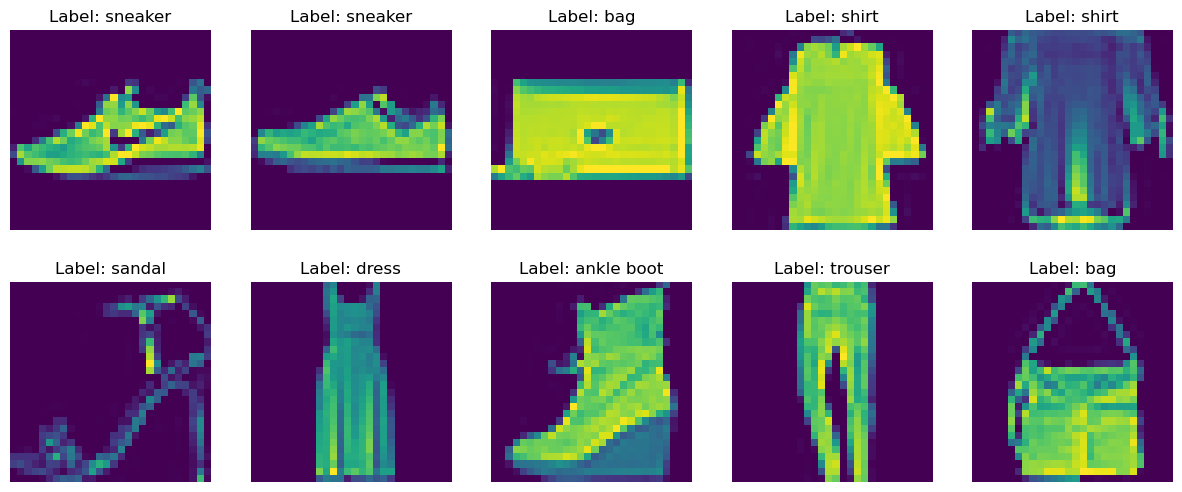

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 选择要绘制的图像索引
indices = np.random.choice(len(train_dataset), size=10, replace=False)  # 随机选择10个图像索引

# 创建画布
fig, axs = plt.subplots(2, 5, figsize=(15, 6))  # 创建2行5列的子图
# figsize=(width, height)
# 如果你有一个 figsize=(15, 6) 的图形，并且你想要放置 2 行 5 列的子图，
# 那么每个子图的大致尺寸将是 15 / 5 = 3 英寸宽和 6 / 2 = 3 英寸高

cmap = 'viridis'  # 选择一个彩色地图，例如 'viridis', 'plasma', 'inferno', 'magma','gray'
text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

# 绘制图像
for row in range(2):
    for col in range(5):
        idx = indices[row * 5 + col]
        img, label = train_dataset[idx]
        img = img.squeeze()  # 去掉单维条目
        axs[row, col].imshow(img, cmap=cmap)  # 使用灰度色图显示图像
        axs[row, col].set_title(f'Label: {text_labels[label]}')
        axs[row, col].axis('off')  # 关闭坐标轴

In [6]:
### 思考
# 1 找出分类错误的样本